# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** [Your Name Here]

**Date:** [Date]

---

## Setup: Install and Load Libraries

In [6]:
pip install tensorflow matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [3]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


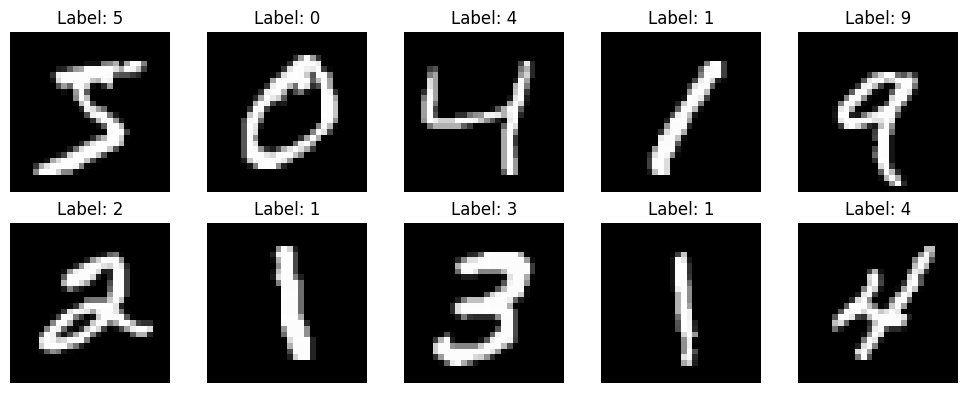

In [4]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [14]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [8]:
# TODO: Build your baseline CNN here
# Architecture:



baseline_cnn = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



# Display model architecture
baseline_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Record training time
print("\nTraining baseline CNN...")
start_time = time.time()

# TODO: Fit the model and store history
history = baseline_cnn.fit(
    X_train_cnn, 
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)  

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test_cnn, y_test, verbose=0)  # Replace with actual evaluation

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)


Training baseline CNN...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7205 - loss: 0.9334 - val_accuracy: 0.9692 - val_loss: 0.1009
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9763 - loss: 0.0787 - val_accuracy: 0.9824 - val_loss: 0.0598
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9850 - loss: 0.0519 - val_accuracy: 0.9855 - val_loss: 0.0488
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9878 - loss: 0.0392 - val_accuracy: 0.9883 - val_loss: 0.0425
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9908 - loss: 0.0307 - val_accuracy: 0.9886 - val_loss: 0.0418
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9927 - loss: 0.0249 - val_accuracy: 0.9888 - val_loss: 0.0399
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9938 - loss: 0.0204 - val_accuracy: 0.9902 - val_loss: 0.0351
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9953

---
## Step 3: Experiment with Filter Counts

In [ ]:
fewer_filters_model = keras.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

print("Training CNN with fewer filters (16, 32)...")
fewer_filters_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = fewer_filters_model.fit(
    X_train_cnn, 
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
) 



test_loss, test_accuracy = fewer_filters_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}") 
print(f"Test Loss: {test_loss:.4f}")

Training CNN with fewer filters (16, 32)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8106 - loss: 0.6422 - val_accuracy: 0.9682 - val_loss: 0.1073
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9724 - loss: 0.0880 - val_accuracy: 0.9812 - val_loss: 0.0650
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9829 - loss: 0.0547 - val_accuracy: 0.9824 - val_loss: 0.0568
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9870 - loss: 0.0423 - val_accuracy: 0.9858 - val_loss: 0.0487
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9890 - loss: 0.0349 - val_accuracy: 0.9854 - val_loss: 0.0465
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9912 - loss: 0.0275 - val_accuracy: 0.9882 - val_loss: 0.0452
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9940 - loss: 0.0198 - val_accuracy: 0.9848 - val_loss: 0.0465
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accura

In [ ]:
more_filters_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
print("Training CNN with more filters (64, 128)...")
more_filters_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = more_filters_model.fit(
    X_train_cnn, 
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
) 


# Evaluate on test set
test_loss, test_accuracy = more_filters_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}") 
print(f"Test Loss: {test_loss:.4f}")

Training CNN with more filters (64, 128)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8659 - loss: 0.4486 - val_accuracy: 0.9796 - val_loss: 0.0694
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9837 - loss: 0.0529 - val_accuracy: 0.9814 - val_loss: 0.0579
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9881 - loss: 0.0377 - val_accuracy: 0.9865 - val_loss: 0.0465
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9921 - loss: 0.0240 - val_accuracy: 0.9877 - val_loss: 0.0423
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9948 - loss: 0.0176 - val_accuracy: 0.9887 - val_loss: 0.0393
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9952 - loss: 0.0142 - val_accuracy: 0.9868 - val_loss: 0.0456
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9965 - loss: 0.0097 - val_accuracy: 0.9893 - val_loss: 0.0442
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step 

### Analysis: Filter Count Effects

**TODO: Write 2-3 sentences answering:**
- How does increasing filter count affect performance?
- At what point do you see diminishing returns or overfitting?


- How does increasing filter count affect performance?
The performance generally the same when increasiong the filters, but it is worth nothing that the less filters was slightly better accuracy wise than the higher filter.
- At what point do you see diminishing returns or overfitting?
The filters seem to have diminishing returns with the test loss value being so hiugh at 9. [Your analysis here]

---
## Step 4: Experiment with Kernel Sizes

In [19]:
larger_kernals_model = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

print("Training CNN with 5x5 kernels...")
larger_kernals_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = larger_kernals_model.fit(
    X_train_cnn, 
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
) 

test_loss, test_accuracy = larger_kernals_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}") 
print(f"Test Loss: {test_loss:.4f}")

Training CNN with 5x5 kernels...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8432 - loss: 0.5249 - val_accuracy: 0.9778 - val_loss: 0.0737
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9831 - loss: 0.0555 - val_accuracy: 0.9747 - val_loss: 0.0814
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9869 - loss: 0.0401 - val_accuracy: 0.9868 - val_loss: 0.0422
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9909 - loss: 0.0291 - val_accuracy: 0.9862 - val_loss: 0.0433
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9932 - loss: 0.0215 - val_accuracy: 0.9876 - val_loss: 0.0403
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9947 - loss: 0.0157 - val_accuracy: 0.9893 - val_loss: 0.0348
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9955 - loss: 0.0138 - val_accuracy: 0.9894 - val_loss: 0.0396
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9955 

In [21]:
mixed_kernals_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

print("Training CNN with mixed kernels (5x5, 3x3)...")
mixed_kernals_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = mixed_kernals_model.fit(
    X_train_cnn, 
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
) 

test_loss, test_accuracy = mixed_kernals_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}") 
print(f"Test Loss: {test_loss:.4f}")

Training CNN with mixed kernels (5x5, 3x3)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8597 - loss: 0.5048 - val_accuracy: 0.9768 - val_loss: 0.0785
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9800 - loss: 0.0625 - val_accuracy: 0.9840 - val_loss: 0.0502
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9874 - loss: 0.0410 - val_accuracy: 0.9872 - val_loss: 0.0427
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9898 - loss: 0.0327 - val_accuracy: 0.9879 - val_loss: 0.0407
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9922 - loss: 0.0250 - val_accuracy: 0.9893 - val_loss: 0.0352
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9942 - loss: 0.0178 - val_accuracy: 0.9887 - val_loss: 0.0357
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9952 - loss: 0.0146 - val_accuracy: 0.9884 - val_loss: 0.0429
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accu

### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

The larger kernels had the ebst accuracy performnce of the model sets with 99.08% acccuracy. It did feel that increasing the kernels genrally increased the eprformance fo the model. Having a bigger kernel size allows for data to be learned morequickly as a bigger area is affected.

---
## Step 5: Train Your Best Architecture and Visualize Learning

In [33]:
# TODO: Based on your experiments, build your best-performing CNN architecture
larger_kernals_model = keras.Sequential([ #.9908 was best accuracy
    layers.Conv2D(32, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

larger_kernals_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = larger_kernals_model.fit(
    X_train_cnn, 
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
) 
best_cnn_time = time.time() - start_time

test_loss, test_accuracy_best = larger_kernals_model.evaluate(X_test_cnn, y_test, verbose=0)

print("Training best CNN architecture...")
start_time = time.time()

best_cnn_time = time.time() - start_time

print(f"\nTest Accuracy: {test_accuracy_best:.4f}") 
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8538 - loss: 0.5061 - val_accuracy: 0.9728 - val_loss: 0.0909
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9806 - loss: 0.0629 - val_accuracy: 0.9851 - val_loss: 0.0510
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9862 - loss: 0.0446 - val_accuracy: 0.9872 - val_loss: 0.0413
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9912 - loss: 0.0284 - val_accuracy: 0.9876 - val_loss: 0.0383
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9928 - loss: 0.0233 - val_accuracy: 0.9898 - val_loss: 0.0341
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9950 - loss: 0.0163 - val_accuracy: 0.9879 - val_loss: 0.0377
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9957 - loss: 0.0143 - val_accuracy: 0.9891 - val_loss: 0.0373
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9961 - loss: 0.0113 - val_accuracy: 0.

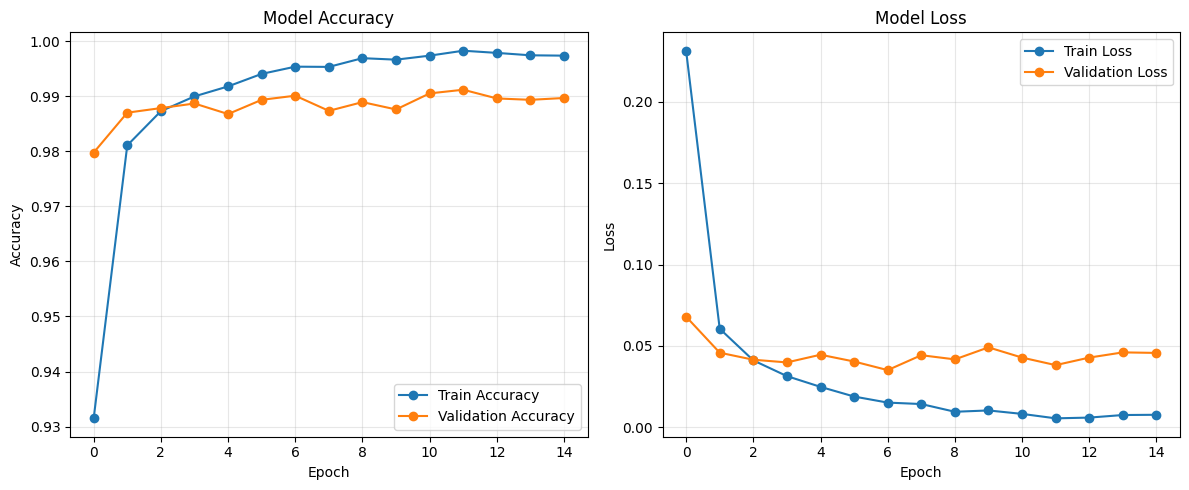

In [23]:
# TODO: Create accuracy plot (training vs validation accuracy over epochs)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [24]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [28]:
# TODO: Build feedforward network
feedforward_nn = keras.Sequential([
    keras.Input(shape=(784,)),       
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  
])

feedforward_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Compile the model

feedforward_nn.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Record training time
print("Training feedforward network...")
start_time = time.time()

history = feedforward_nn.fit(
    X_train_flat,   
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)



# Record training time
feedforward_time = time.time() - start_time

test_loss, test_accuracy_feedforward = feedforward_nn.evaluate(X_test_flat,  y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy_feedforward:.4f}")
print(f"Test Loss: {test_loss:.4f}")



Training feedforward network...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8024 - loss: 0.6922 - val_accuracy: 0.9488 - val_loss: 0.1793
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9507 - loss: 0.1699 - val_accuracy: 0.9603 - val_loss: 0.1408
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9650 - loss: 0.1178 - val_accuracy: 0.9678 - val_loss: 0.1084
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9764 - loss: 0.0823 - val_accuracy: 0.9700 - val_loss: 0.1000
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9794 - loss: 0.0670 - val_accuracy: 0.9717 - val_loss: 0.0961
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9854 - loss: 0.0498 - val_accuracy: 0.9734 - val_loss: 0.0868
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9884 - loss: 0.0400 - val_accuracy: 0.9749 - val_loss: 0.0869
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9911 -

In [35]:
# TODO: Create comparison table

comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        'Baseline',
        'BEst',
        'FeedForward'
    ],
    'Test Accuracy': [
        baseline_test_acc,   # replace with your variable
        test_accuracy_best,            # from best CNN
        test_accuracy_feedforward          # from feedforward NN
    ],
    'Training Time (s)': [
        baseline_time,            # replace with your variable
        best_cnn_time,            # from best CNN
        feedforward_time          # from feedforward NN
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model Architecture  Test Accuracy  Training Time (s)
  Baseline CNN     Baseline         0.9895          41.168104
      Best CNN         BEst         0.9919           0.000000
Feedforward NN  FeedForward         0.9752          10.743015


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

My best was better tahn feedforward entwork with an accuarcy of 99.19% vs 97.52%. I think spacial awareness allow for more patterns to be made and generally mroe data to be gathered/learned in this context.

---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

It is not something I wanted to explore in my project and I feel that want to focus on logistic regression more so than CNN and RNN. Those particular methods would be better suited for my project. My dataset for the project is tabular oriented which not benefit from neural networks as that of images would, so I want to stick with my methods instead. 

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.